## fancyimpute
- 결측값을 고급 알고리즘을 이용해 채워주는 python package
- 대표적인 기능
  - KNN(), IterativeImputer(), MatrixFactorization(), SoftImpute(), SimpleFill()

In [1]:
pip install fancyimpute

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.8 MB/s eta 0:00:00
  Created wheel for fancyimpute: filename=fancyimpute-0.7.0-py3-none-any.whl size=29879 sha256=196f02326d758332e2e7cfa0fb38e544bfb7ce0c7b69ff9c679d0e406c189661
  Stored in directory: /root/.cache/pip/wheels/1a/f3/a1/f7f10b5ae2c2459398762a3fcf4ac18c325311c7e3163d5a15
  Created wheel for knnimpute: filename=knnimpute-0.1.0-py3-none-any.whl size=11331 sha256=f4aa5430c99c4ecb8f3e36f76a5a0894ab366452749de2e6c8ac88d8adedd705
  Stored in directory: /root/.cache/pip/wheels/ea/e8/e0/79872972161e54486517ae507f94b2c7cea27fb7ef793bd415
Successfully built fancyimpute knnimpute


In [2]:
## 데이터 분석 & 시각화 도구에 필요한 library 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 결측치 처리 도구 불러오기
from sklearn.impute import SimpleImputer, KNNImputer
from fancyimpute import IterativeImputer

## 평가 지표 (오차계산) 도구 불러오기
from sklearn.metrics import mean_squared_error

In [3]:
## 정규분포에서 난수 생성(N(10, 2))
np.random.seed(1)  # 난수 고정
data = np.random.normal(10, 2, 100)

In [4]:
data.shape

(100,)

In [5]:
## numpy 배열 data를 pandas DataFrame으로 변환하고 열 이름을 'feature'로 설정
df_fin = pd.DataFrame(data, columns=['feature'])

In [7]:
df_fin.shape

(100, 1)

In [8]:
## 결측치 삽입을 위한 복사본 df_missing 만들기
df_missing = df_fin.copy()

In [9]:
## 결측치 생성 -> 특정 행의 값을 NaN으로 설정
df_missing.loc[5:10, 'feature'] = np.nan
df_missing.loc[30:35, 'feature'] = np.nan
df_missing.loc[40:55, 'feature'] = np.nan

In [11]:
df_missing.isna().sum()

,0
feature,28


## df_missing 에 대해 결측치 대체하는 과정

In [12]:
## 선형 보간 (Linear Interpolation)
df_linear = df_missing.interpolate(method='linear')

## 2차 곡선 보간 (Quadratic Interpolation)
df_quadratic = df_missing.interpolate(method='quadratic')

## 평균값 대체 (Mean Imputation)
df_mean = pd.DataFrame(SimpleImputer(strategy='mean').fit_transform(df_missing), columns=['feature'])

## 0으로 대체 (Zero Imputation)
df_zero = df_missing.fillna(0)

## KNN (K-Nearest Neighbors Imputation)
df_knn = pd.DataFrame(KNNImputer(n_neighbors=3).fit_transform(df_missing), columns=['feature'])

## MICE (다중 분산 회귀: Multiple Imputation by Chained Equations)
df_mice = pd.DataFrame(IterativeImputer(random_state=111).fit_transform(df_missing), columns=['feature'])

## 데이터가 어떤 식으로 결측치를 대치한 것인가?
- 결측치 처리 방법들이 실제 데이터에 어떤 영향을 주었는지 시각적으로 비교하기 위한 시계열 그래프
- 결측 포함 원본 데이터, 결측 없는 원본 데이터, 선형 보간, 2차곡선 보간, 평균값, 0, KNN, MICE -> 총 8개 비교

Text(0.5, 1.0, 'Multiple Imputation by Chained Equations')

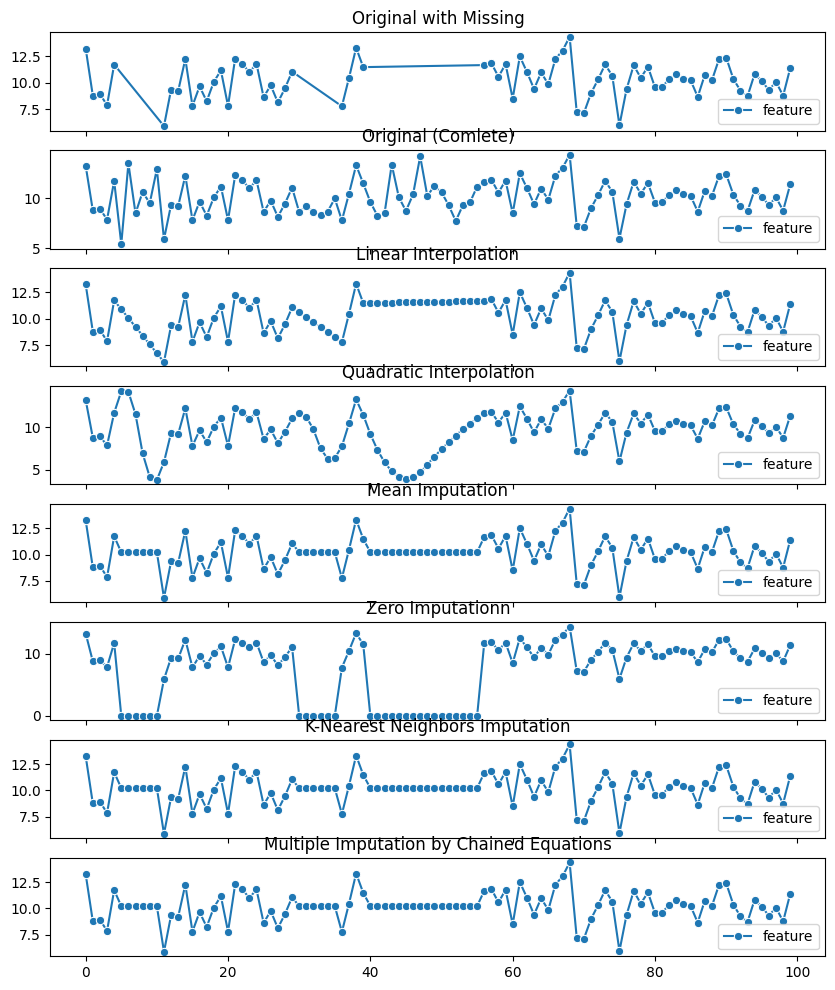

In [14]:
## 총 8개의 X축 공유 subplot 만들기
fig, axs = plt.subplots(8, 1, figsize=(10, 12), sharex=True)

## 1. 원본 데이터 (결측 포함)
sns.lineplot(data=df_missing, marker='o', ax=axs[0], color='gray')
axs[0].set_title('Original with Missing')

## 2. 완전한 원본 (결측 없는 원래 데이터)
sns.lineplot(data=df_fin, marker='o', ax=axs[1], color='black')
axs[1].set_title('Original (Comlete)')

## 3. 선형 보간
sns.lineplot(data=df_linear, marker='o', ax=axs[2], color='black')
axs[2].set_title('Linear Interpolation')

## 4. 2차 곡선 보간
sns.lineplot(data=df_quadratic, marker='o', ax=axs[3], color='black')
axs[3].set_title('Quadratic Interpolation')

## 5. 평균값 대체
sns.lineplot(data=df_mean, marker='o', ax=axs[4], color='black')
axs[4].set_title('Mean Imputation')

## 6. 0 대체
sns.lineplot(data=df_zero, marker='o', ax=axs[5], color='black')
axs[5].set_title('Zero Imputationn')

## 7. KNN
sns.lineplot(data=df_knn, marker='o', ax=axs[6], color='black')
axs[6].set_title('K-Nearest Neighbors Imputation')

## 8. MICE
sns.lineplot(data=df_mice, marker='o', ax=axs[7], color='black')
axs[7].set_title('Multiple Imputation by Chained Equations')

## 결측치 대체 방법의 성능 비교
- 실제 값과 결측치를 대치한 값과 비교하면 된다.
- (실제값과 예측값의 차이를 비교하면 된다!, 어떤 게 가장 차이가 적나?)
- 비교 기준은 MSE

In [17]:
## 결측치 위치 추출
missing_idx = df_missing[df_missing['feature'].isnull()].index

## 각 방식에 대한 MSE 계산
res = {
    'Linear' :mean_squared_error(df_fin.loc[missing_idx], df_linear.loc[missing_idx]),
    'Quadratic' :mean_squared_error(df_fin.loc[missing_idx], df_quadratic.loc[missing_idx]),
    'Mean' :mean_squared_error(df_fin.loc[missing_idx], df_mean.loc[missing_idx]),
    'Zero' :mean_squared_error(df_fin.loc[missing_idx], df_zero.loc[missing_idx]),
    'KNN' :mean_squared_error(df_fin.loc[missing_idx], df_knn.loc[missing_idx]),
    'MICE' :mean_squared_error(df_fin.loc[missing_idx], df_mice.loc[missing_idx]),
}

## 결과를 DataFrame으로 정리하고 오름차순 정렬
res_df = pd.DataFrame.from_dict(res, orient='index', columns=['MSE']).sort_values('MSE')

In [18]:
## MSE 값이 작을수록 성능이 우수
res_df

,MSE
Mean,3.686203
KNN,3.686203
MICE,3.686203
Linear,6.372685
Quadratic,20.721454
Zero,100.790670


In [19]:
## 원래 데이터의 중심 경향과 분포 특성
df_fin.describe()

,feature
count,100.000000
mean,10.121166
std,1.779231
min,5.396923
25%,8.772365
50%,10.128148
75%,11.274821
max,14.371151


(array([ 3.,  1.,  6., 17., 19., 20., 14., 12.,  5.,  3.]),
 array([ 5.39692261,  6.29434543,  7.19176825,  8.08919107,  8.98661389,
         9.88403671, 10.78145953, 11.67888235, 12.57630517, 13.47372799,
        14.37115081]),
 <BarContainer object of 10 artists>)

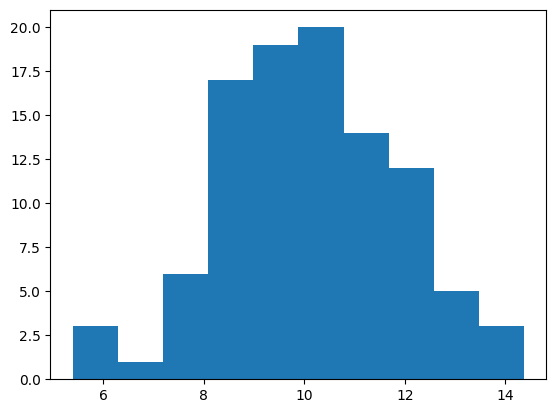

In [20]:
## 시각화를 통해 중심이 10 근처에 있고, 정규분포에 가깝다는 것을 파악
plt.hist(df_fin)